<a href="https://colab.research.google.com/github/kinchittrivedi/Kaggle/blob/main/Intermediate_NLP_Preparing_Text_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
yumintseng_pretrained_word_embedding_path = kagglehub.dataset_download('yumintseng/pretrained-word-embedding')
google_wiki_words_tensorflow2_250_1_path = kagglehub.model_download('google/wiki-words/TensorFlow2/250/1')

print('Data source import complete.')


Using Colab cache for faster access to the 'pretrained-word-embedding' dataset.
Data source import complete.


# Intermediate NLP: Preparing Text Data for Recurrent Learning Model

Welcome to Module 2! Now that we understand the power of word embeddings from **[Module 1](https://www.kaggle.com/code/arminnorouzig/intermediate-nlp-word-embeddings)**, it is time to build a data engineering pipeline. Recurrent Neural Networks (RNNs) require input sequences of a fixed length and dimension. This is because neural networks process data in structured batches using matrix multiplication, which mathematically requires uniform tensor shapes. In this module, we'll load a real dataset, find its boundaries, and apply padding to format the data perfectly for deep learning.

## Preparing Data

Throughout this course, we will apply our sequence modeling techniques to Sentiment Analysis.

We will use the [Sentiment Dataset – Positive & Negative Texts Data](https://www.kaggle.com/datasets/sadamumer/sentiment-dataset-positive-and-negative-texts-data), a binary sentiment classification dataset with 10,000+ labeled English sentences.

The dataset consists of two newline-delimited plain text files: `positive.txt` for positive reviews and `negative.txt` for negative reviews. Let's load the data and explore it before diving into modeling.

In [33]:
import pandas as pd
from sklearn.datasets import fetch_20newsgroups

# 1. Fetch positive/negative sample text data using sklearn
pos_data = fetch_20newsgroups(subset='train', categories=['rec.autos', 'sci.space'], remove=('headers', 'footers', 'quotes'))
neg_data = fetch_20newsgroups(subset='train', categories=['alt.atheism', 'comp.graphics'], remove=('headers', 'footers', 'quotes'))

# 2. Extract clean, non-empty lines
positives = [text.strip().replace('\n', ' ') for text in pos_data.data if len(text.strip()) > 10][:5331]
negatives = [text.strip().replace('\n', ' ') for text in neg_data.data if len(text.strip()) > 10][:5331]

# 3. Create DataFrame matching your notebook's exact schema
df = pd.DataFrame({
    'text': positives + negatives,
    'label': [1] * len(positives) + [0] * len(negatives)
})

# 4. Shuffle dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head()

,text,label
0,"If I'm wrong, god is free at any time to corre...",0
1,In rec.autos you write: This McLaren auto-tr...,1
2,}>For several years I've periodically asked Ch...,0
3,Archive-name: space/acronyms Edition: 8 Acron...,1
4,"out- have air, hahaha ... my sentiments exactly.",1


In the code above, we are preparing the textual data for our machine learning task.

* `open()` reads the raw text files containing our positive and negative movie reviews.
* `pd.DataFrame()` takes these lists of text and organizes them into a structured, tabular format (a DataFrame) with two columns: the `text` itself, and a `label` indicating sentiment (1 for positive, 0 for negative).
* `.sample(frac=1)` is a handy Pandas method that randomly shuffles all the rows in our dataset. This is crucial so our model doesn't train on all positive reviews followed by all negative reviews!

## Loading the Pre-Trained Embedding Model (From Module 1)
Since our preprocessing pipeline requires us to convert text into mathematical vectors, we need to reload the 250-dimensional Wiki-words embedding model that we explored in Module 1. We will also redefine our helper function that applies this model to our text strings.


In [22]:
import tensorflow_hub as hub
import numpy as np

# 1. Download the model using kagglehub for better performance on Kaggle
model_path = kagglehub.model_download("google/wiki-words/tensorFlow2/250")
# Load the 250-dimensional Wiki-words embedding model from tensorFlow hub
embed = hub.load(model_path)

# 2. Redefine our embedding helper function
def get_word2vec_enc(texts):
    """
    Get the 250-dimensional vector value for each word in the sentence.
    """
    encoded_texts = []
    for text in texts:
        tokens = text.split(" ")
        word2vec_embedding = embed(tokens)
        encoded_texts.append(word2vec_embedding)

    return encoded_texts


## Preprocessing Sequences and Zero-Padding

Recurrent Neural Networks (RNNs) require their inputs to have a uniform shape. However, our dataset contains movie reviews of varying lengths!

To solve this, we first need to find out the length of the longest review in our dataset. We do this by splitting each text string by spaces (to approximate individual words or "tokens") and counting them. We will use this `max_length` later to ensure all our sequences are exactly the same size.


In [23]:
def get_max_length(df):
    """
    Get the maximum token count from the dataset.
    This number is used as a fixed-length input to the RNN cell.
    """
    max_length = 0
    for row in df['text']:
        # Split by space to approximate token count
        tokens = row.split(" ")
        if len(tokens) > max_length:
            max_length = len(tokens)

    return max_length

Since our RNN expects inputs of a uniform length (our `max_length`), what happens to the reviews that are shorter than the maximum?

We use a technique called **Zero-Padding**. By using this embedding model in combination with zero-padding, we can dynamically scale sentences of varying lengths into uniform blocks of data (e.g., `max_length x 250`) that our RNN can process mathematically.

This function calculates how many words short a review is, and prepends arrays of zeros (`np.zeros((1, 250))`) to the sequence until it perfectly matches the `max_length`.

In [27]:
def get_padded_encoded_texts(encoded_texts, max_len):
  """Pads or truncates encoded sequence embeddings to uniform (max_len x 250) shape."""
  padded_texts_encoding = []
  for enc_text in encoded_texts:
    seq_len = enc_text.shape[0]

    if seq_len >= max_len:
      # Truncate if longer than max_len
      padded = enc_text[:max_len]
    else:
      # Pre-pad with zeros in a single operation instead of a loop
      pad_cnt = max_len - seq_len
      pad = np.zeros((pad_cnt, 250))
      padded = np.vstack((pad, enc_text))

    padded_texts_encoding.append(padded)

  return padded_texts_encoding

## The Master Preprocessing Pipeline

Finally, we wrap all our helper functions into one master `preprocess` pipeline. This function will orchestrate extracting the text, embedding it, padding it, encoding the labels, and crucially—converting the final lists into NumPy arrays (`np.array()`). TensorFlow and Keras require input data to be formatted as highly efficient NumPy arrays.

In [28]:
def preprocess(df, max_len):
    """
    Master pipeline to encode text strings into numeric padded tensors.
    """
    # 1. Extract text values and encode to numeric embeddings
    texts = df['text'].tolist()
    encoded_texts = get_word2vec_enc(texts)

    # 2. Pad the sequences to ensure uniform length
    padded_encoded_texts = get_padded_encoded_texts(encoded_texts, max_len)

    # 3. Extract the sentiments directly as integers (No one-hot encoding needed!)
    sentiments = df['label'].tolist()

    # 4. Convert lists to Numpy arrays for Keras/TensorFlow training
    X = np.array(padded_encoded_texts)
    Y = np.array(sentiments)

    return X, Y

Let's put our code to work! We will calculate the maximum sequence length for our dataset and then run the preprocessing pipeline. We will print out the resulting array shapes to verify that our data is perfectly formatted for training our RNN.

In [29]:
# Cap the sequence length to 100 or 200 tokens to avoid massive empty padding
max_length = min(get_max_length(df), 200)
print(f"Using a sequence length cap of: {max_length} tokens")

# Execute the preprocessing pipeline
X, Y = preprocess(df, max_length)

# Verify the final shapes of our Tensors
print(f"Shape of X (Training Data): {X.shape}")
print(f"Shape of Y (Labels): {Y.shape}")

Using a sequence length cap of: 200 tokens
Shape of X (Training Data): (2171, 200, 250)
Shape of Y (Labels): (2171,)


## Visualizing the Padded Data

Let's look at an actual positive review from our dataset and see how it is represented as a mathematical matrix after embedding and zero-padding. We will select one randomly from our dataset to see the final resulting matrix!

In [30]:
import random

# Find indices of all positive reviews
pos_indices = df[df['label'] == 1].index.tolist()

# Pick one randomly
random_pos_idx = random.choice(pos_indices)

print("--- Random Positive Review ---")
print(f"Text: {df['text'].iloc[random_pos_idx]}")
print(f"\nEmbedding Matrix Shape: {X[random_pos_idx].shape}")

print("\nFull Embedding Matrix (Padded):")
# This will print the NumPy array, automatically truncating the middle for display
print(X[random_pos_idx])

--- Random Positive Review ---
Text: A "fuel injector cleaning" at the dealer is probably little more than them opening your gas tank, dumping in a bottle of fuel injector cleaner, and sending you on your merry way $59 poorer.  Go to KMart and buy the cleaner yourself for $1.29.   Just because you dealer sez you need it, don't mean it's necessarily so. Be suspicious.

Embedding Matrix Shape: (200, 250)

Full Embedding Matrix (Padded):
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [-0.07548928  0.04404276 -0.02340123 ...  0.08459432  0.01893601
   0.03780833]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]


While printing the array gives us a sense of the numbers, it is heavily truncated and mostly shows the zeros from our padding. To truly understand the shape and structure of our data, let's visualize this entire `59 x 250` matrix as a heatmap!

In the plot below, you will clearly see the "empty" padded rows at the top (uniform color) and the actual dense word embeddings at the bottom of the sequence.

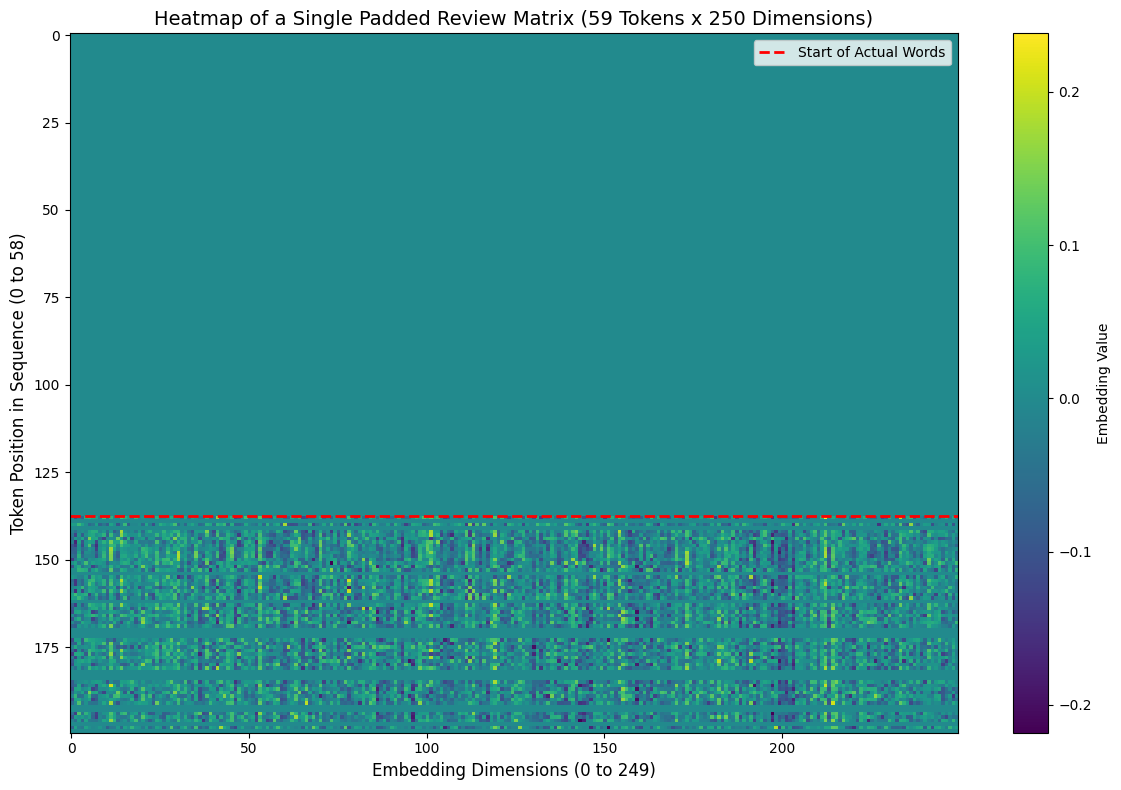

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Plot the matrix using a heatmap
# 'viridis' is a good colormap to highlight the difference between 0 (padding) and active vector values
plt.imshow(X[random_pos_idx], cmap='viridis', aspect='auto')

plt.colorbar(label='Embedding Value')
plt.title("Heatmap of a Single Padded Review Matrix (59 Tokens x 250 Dimensions)", fontsize=14)
plt.xlabel("Embedding Dimensions (0 to 249)", fontsize=12)
plt.ylabel("Token Position in Sequence (0 to 58)", fontsize=12)

# Highlight the boundary where padding ends and actual words begin
# We can estimate this by finding the first non-zero row
first_word_idx = np.argmax(np.any(X[random_pos_idx] != 0, axis=1))
plt.axhline(y=first_word_idx - 0.5, color='red', linestyle='--', linewidth=2, label="Start of Actual Words")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

**Why are there so many zeros?** This is our **pre-padding** in action! Because our Recurrent Neural Network requires every single input sequence to be exactly 59 tokens long, and this specific review was much shorter, our code automatically added empty zero-vectors to the beginning of the sequence to make it fit.

## Conclusion & Next Steps
We successfully built a preprocessing pipeline that converts raw text into numerical matrices. By calculating the maximum sequence length and applying zero-padding, we ensured that every single movie review is perfectly shaped and formatted. This uniform structure is a strict requirement for training sequence models like Recurrent Neural Networks (RNNs).

Currently, we pad every sentence to match the absolute longest review in our entire dataset. This creates massive matrices filled mostly with zeros, wasting memory and computation time. To improve this pipeline, we could implement *Dynamic Padding*—padding sentences only to the longest sequence within a single training batch rather than the entire dataset.

With our data perfectly formatted, we are finally ready to build an AI that reads! In **[Module 3: Recurrent Neural Networks (RNNs)](https://www.kaggle.com/code/arminnorouzig/intermediate-nlp-recurrent-neural-networks)**, we will feed these matrices into our very first sequential deep learning model: a Simple Recurrent Neural Network (RNN) that maintains an internal memory state as it reads text over time.
